In [1]:
import pandas as pd
import numpy as np
import os

In [4]:
profile_data_file = "../real_vase_files/profiles_stratified_120526.parquet"
meta_data_file = "../real_vase_files/master_metadata.csv"
OUT_DIR = "pca_csv_stratified_120526"  # Must match _BASE in app/vase/potgen.py

In [3]:
# Read the metadata file
meta_data = pd.read_csv(meta_data_file, encoding='latin1', 
                        dtype=str)

# Read the profile data file
profile_data = pd.read_parquet(profile_data_file)

# Ensure 'gpp_no' columns are of the same type
meta_data['gpp_no'] = meta_data['gpp_no'].astype(str).str.strip()
profile_data['gpp_no'] = profile_data['gpp_no'].astype(str).str.strip()

profile_data['gpp_no'] = profile_data['gpp_no'].str.replace('_large', '')
profile_data['gpp_no'] = profile_data['gpp_no'].str.replace('(1)', '')
profile_data['gpp_no'] = profile_data['gpp_no'].str.replace('jpeg', '')

# Check for missing values in 'gpp_no'
print("Missing values in meta_data['gpp_no']:", meta_data['gpp_no'].isnull().sum())
print("Missing values in profile_data['gpp_no']:", profile_data['gpp_no'].isnull().sum())

# Compare unique 'gpp_no' values in both datasets
meta_gpp_no = set(meta_data['gpp_no'].unique())
profile_gpp_no = set(profile_data['gpp_no'].unique())

# Identify non-matching keys
missing_in_meta = profile_gpp_no - meta_gpp_no
missing_in_profile = meta_gpp_no - profile_gpp_no

print(f"Number of 'gpp_no' in profile_data not in meta_data: {len(missing_in_meta)}")

# Optionally, print a few examples of missing keys
print("Examples of 'gpp_no' in profile_data but not in meta_data:", list(missing_in_meta)[:10])

print(missing_in_meta)

# Merge the two dataframes based on the 'gpp_no' column
merged_data = pd.merge(meta_data, profile_data, on='gpp_no')

Missing values in meta_data['gpp_no']: 0
Missing values in profile_data['gpp_no']: 0
Number of 'gpp_no' in profile_data not in meta_data: 3
Examples of 'gpp_no' in profile_data but not in meta_data: ['bm_franks.254.+_', 'bapd_9006424', 'met_48418']
{'bm_franks.254.+_', 'bapd_9006424', 'met_48418'}


In [5]:
print(len(profile_data['gpp_no'].unique()))
print(len(merged_data['gpp_no'].unique()))

53155
53152


In [6]:
from pca_func_new import pca_run
pca_df, explained_variance, cum_sum, pca_vals_df, means, pca_result, pca, d, gone_list = pca_run(merged_data, 0)

Removed 0 vases.
0 by height-to-width ratio and 0 by width ratio.
6
[0.58 0.82 0.91 0.95 0.97 0.98]


Adding culture_general: 100%|██████████| 53152/53152 [00:00<00:00, 5011479.07it/s]


In [7]:
os.makedirs(OUT_DIR, exist_ok=True)
# Save PCA components (eigenvectors) — shape (n_components, n_features).
# potgen.py reads this as the projection matrix to reconstruct vase coordinates.
pca_vals_df.to_csv(f'{OUT_DIR}/pc_vals.csv', index=True)

In [8]:
# Calculate min and max for PC1–PC10 (app uses PC1–PC6; extra rows are ignored)
used_pcs = [f'PC{i}' for i in range(1, 7)]
pc_min_max = pd.DataFrame({
    'PC': used_pcs,
    'min': pca_df[used_pcs].min().values,
    'max': pca_df[used_pcs].max().values
})
pc_min_max.to_csv(f"{OUT_DIR}/pc_val_ranges.csv", index=False)

In [9]:
means_df = pd.DataFrame(means, columns=["mean_values"])
means_df.to_csv(f'{OUT_DIR}/pc_val_means.csv', header=['pc_mean'], index=False)

In [10]:
# Validate: reconstruct vase coordinates from PCA scores and confirm near-zero error
reconstructed = (pca_result @ pca.components_) + pca.mean_
original_data = d.drop(columns=['gpp_no']).values
reconstruction_mse = np.mean((original_data - reconstructed) ** 2)
print(f"Reconstruction MSE: {reconstruction_mse:.2e}")  # Should be ~0

Reconstruction MSE: 1.42e-03


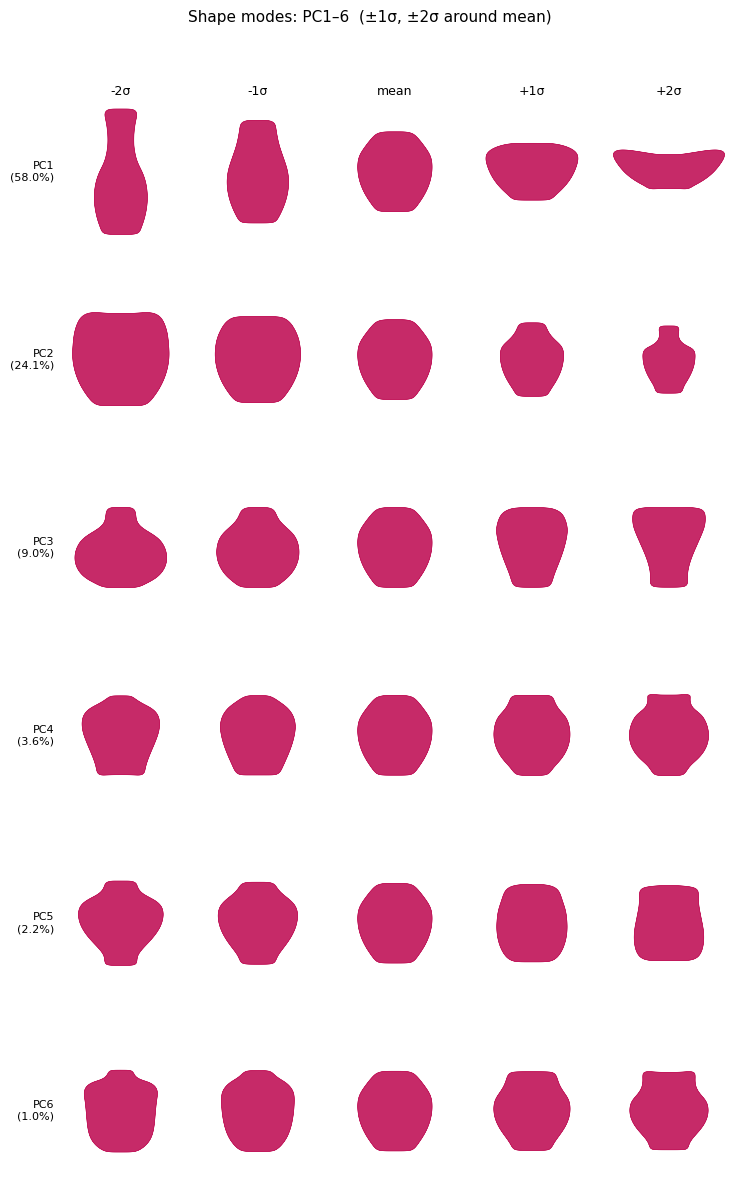

Saved → pca_csv_stratified_120526/shape_modes.png


In [11]:
import matplotlib.pyplot as plt

SIGMAS     = [-2, -1, 0, 1, 2]
N_PCS_PLOT = 6
COL_FILL   = "#C2185B"

n_pts = pca.mean_.shape[0] // 2          # 125 profile points (x block, then y block)
sds   = np.sqrt(pca.explained_variance_)  # 1 SD per PC

def backproject(pc_idx, sigma):
    """Return full mirrored silhouette coords for mean + sigma*SD along one PC."""
    shape = pca.mean_ + sigma * sds[pc_idx] * pca.components_[pc_idx]
    xs    = shape[:n_pts]   # x-coords (half-profile, 0 = centreline)
    ys    = shape[n_pts:]   # y-coords
    # mirror: left half = -x reversed, right half = x
    xs_full = np.concatenate([-xs[::-1], xs])
    ys_full = np.concatenate([ys[::-1],  ys])
    return xs_full, ys_full

# Pre-compute all shapes to share a common axis range across every panel
all_shapes = [backproject(pc, s) for pc in range(N_PCS_PLOT) for s in SIGMAS]
all_x = np.concatenate([s[0] for s in all_shapes])
all_y = np.concatenate([s[1] for s in all_shapes])
xpad  = (all_x.max() - all_x.min()) * 0.05
ypad  = (all_y.max() - all_y.min()) * 0.05
xlim  = (all_x.min() - xpad, all_x.max() + xpad)
ylim  = (all_y.min() - ypad, all_y.max() + ypad)

fig, axes = plt.subplots(N_PCS_PLOT, len(SIGMAS),
                         figsize=(len(SIGMAS) * 1.5, N_PCS_PLOT * 2.0))

k = 0
for pc in range(N_PCS_PLOT):
    ve_pct = explained_variance[pc] * 100
    for j, sigma in enumerate(SIGMAS):
        ax = axes[pc, j]
        xs_full, ys_full = all_shapes[k]; k += 1

        ax.fill(xs_full, ys_full, color=COL_FILL, alpha=0.92,
                edgecolor=COL_FILL, linewidth=0.4)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if pc == 0:
            ax.set_title("mean" if sigma == 0 else f"{sigma:+d}σ", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"PC{pc+1}\n({ve_pct:.1f}%)",
                          rotation=0, ha="right", va="center", fontsize=8)

fig.suptitle("Shape modes: PC1–6  (±1σ, ±2σ around mean)", fontsize=11, y=1.01)
fig.tight_layout()
plt.savefig(f"{OUT_DIR}/shape_modes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/shape_modes.png")